In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Optional, Literal, List
from langgraph.graph import StateGraph, START, END

load_dotenv()

d:\factlens\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [4]:
class DetectorResult(TypedDict, total=False):
    audio_languages: List[str]

In [5]:
class AudioLangAndText(TypedDict):
    language: str
    text : str

In [6]:
class Claim(TypedDict):
    claim: str
    claim_type: str

In [7]:
class FactLensState(TypedDict, total=False):

    video_path: str

    valid: bool
    readable: bool
    error: str

    filename: str
    extension: str
    mime_type: str

    file_size_bytes: int
    file_size_mb: float

    duration_seconds: float
    fps: float
    frame_count: int
    resolution: str

    audio_path: str

    whisper_result: DetectorResult
    mms_result: DetectorResult

    audio_languages: List[str]

    audio_language_and_text: AudioLangAndText

    audio_text: str
    audio_text_eng: str

    ocr_languages: List[str]
    video_text: str

    merged_context: str

    claims: List[Claim]

In [8]:
# function that take the file path and return video file

from pathlib import Path

def get_video_file(file_path: str):
    """
    Returns an opened video file object if it exists.
    Returns None if the file doesn't exist.
    """
    path = Path(file_path)

    if not path.exists():
        print(f"File not found: {file_path}")
        return None

    return open(path, "rb")

In [9]:
import os
import cv2
import mimetypes
import os
import subprocess

def extract_audio(file_path: str) -> str:
    """Extracts audio from video and saves it to the temp1 folder as 16kHz mono WAV."""

    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"Input file not found: {file_path}"
        )

    temp_dir = os.path.join(
        os.getcwd(),
        "temp1"
    )

    os.makedirs(
        temp_dir,
        exist_ok=True
    )

    audio_name = (
        f"{Path(file_path).stem}.wav"
    )

    temp_audio_path = os.path.join(
        temp_dir,
        audio_name
    )

    if os.path.exists(temp_audio_path):

        try:
            os.remove(temp_audio_path)
        except PermissionError:
            pass

    cmd = [
        "ffmpeg",
        "-y",
        "-i",
        file_path,
        "-vn",
        "-acodec",
        "pcm_s16le",
        "-ar",
        "16000",
        "-ac",
        "1",
        temp_audio_path,
    ]

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    if result.returncode != 0:

        raise RuntimeError(
            "FFmpeg audio extraction failed:\n"
            + result.stderr[-2000:]
        )

    return temp_audio_path


def metadata_extraction_node(state: FactLensState) -> dict:
    video_path = state["video_path"]

    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video not found: {video_path}")

    filename = os.path.basename(video_path)
    extension = os.path.splitext(filename)[1].lower()
    mime_type, _ = mimetypes.guess_type(video_path)
    file_size = os.path.getsize(video_path)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return {
            "valid": False,
            "readable": False,
            "error": "Unable to open video."
        }

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = frame_count / fps if fps > 0 else 0

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    # Extract the audio ONCE here before starting parallel detection
    try:
        audio_path = extract_audio(video_path)
    except Exception as e:
        return {
            "valid": False,
            "readable": False,
            "error": f"Audio extraction failed: {str(e)}"
        }

    return {
        "valid": True,
        "filename": filename,
        "extension": extension,
        "mime_type": mime_type,
        "file_size_bytes": file_size,
        "file_size_mb": round(file_size / (1024 * 1024), 2),
        "duration_seconds": round(duration, 2),
        "fps": round(fps, 2),
        "frame_count": frame_count,
        "resolution": f"{width}x{height}",
        "readable": True,
        "audio_path": audio_path, # Saved to state
    }

In [10]:
import os
from collections import Counter

import cv2
import torch
import librosa
import whisper
import easyocr
from langdetect import detect_langs
from transformers import Wav2Vec2ForSequenceClassification, AutoFeatureExtractor

MMS_MODEL_NAME = "facebook/mms-lid-4017"

MMS_PROCESSOR = AutoFeatureExtractor.from_pretrained(
    MMS_MODEL_NAME
)

MMS_MODEL = Wav2Vec2ForSequenceClassification.from_pretrained(
    MMS_MODEL_NAME
)

MMS_MODEL.eval()

# Mapping ISO-639-3 (3-letter) outputs from facebook/mms-lid-401 to ISO-639-1 (2-letter)
MMS_ISO_MAP = {
    "hin": "hi", "eng": "en", "urd": "ur", "guj": "gu",
    "pan": "pa", "bng": "bn", "tam": "ta", "tel": "te",
    "kan": "kn", "mal": "ml", "mar": "mr", "ori": "or",
    "spa": "es", "fra": "fr", "deu": "de", "ita": "it",
    "rus": "ru", "zho": "zh", "jpn": "ja", "kor": "ko",
    "ara": "ar", "tur": "tr", "por": "pt", "vie": "vi"
}

WHISPER_LID_MODEL = whisper.load_model("tiny")

USE_GPU = torch.cuda.is_available()

OCR_READER_HI = easyocr.Reader(
    ["en", "hi"],
    gpu=USE_GPU
)

OCR_READER_UR = easyocr.Reader(
    ["en", "ur"],
    gpu=USE_GPU
)
# =====================================================================
# 2. AUDIO & OCR EXTRACTION HELPERS
# =====================================================================

def detect_ocr_languages(video_path: str) -> List[str]:

    if not os.path.exists(video_path):
        return []

    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps <= 0:
        fps = 30

    frame_interval = max(
        1,
        int(fps * 2)
    )

    frame_count = 0
    extracted_texts = []

    while cap.isOpened():

        ret, frame = cap.read()

        if not ret:
            break

        if frame_count % frame_interval == 0:

            res_hi = OCR_READER_HI.readtext(
                frame,
                detail=0
            )

            res_ur = OCR_READER_UR.readtext(
                frame,
                detail=0
            )

            extracted_texts.extend(res_hi)
            extracted_texts.extend(res_ur)

        frame_count += 1

        if frame_count > fps * 30:
            break

    cap.release()

    combined_text = " ".join(
        extracted_texts
    ).strip()

    if not combined_text:
        return []

    try:

        predictions = detect_langs(
            combined_text
        )

        return sorted(
            {
                pred.lang
                for pred in predictions
                if pred.prob > 0.20
            }
        )

    except Exception as e:

        print(f"[OCR language detection error] {e}")

        return []
# =====================================================================
# 3. ACTUAL MODEL CLASSIFICATION LOGIC
# =====================================================================
def run_whisper_audio(audio_path: str) -> List[str]:

    try:

        audio = whisper.load_audio(audio_path)
        audio = whisper.pad_or_trim(audio)

        mel = whisper.log_mel_spectrogram(
            audio
        ).to(WHISPER_LID_MODEL.device)

        _, probs = WHISPER_LID_MODEL.detect_language(mel)

        detected = max(
            probs,
            key=probs.get
        )

        return [detected] if detected else []

    except Exception as e:

        print(f"[Whisper Error] {e}")

        return []
    
def run_mms_audio(audio_path: str) -> List[str]:

    try:

        speech, _ = librosa.load(
            audio_path,
            sr=16000,
            mono=True
        )

        inputs = MMS_PROCESSOR(
            speech,
            sampling_rate=16000,
            return_tensors="pt"
        )

        with torch.no_grad():

            outputs = MMS_MODEL(**inputs)

            predicted_id = torch.argmax(
                outputs.logits,
                dim=-1
            ).item()

        lang_3 = MMS_MODEL.config.id2label[predicted_id]

        lang_2 = MMS_ISO_MAP.get(
            lang_3.lower(),
            lang_3.lower()
        )

        return [lang_2]

    except Exception as e:

        print(f"[MMS Error] {e}")

        return []

# =====================================================================
# 4. PARALLEL NODES (Corrected to use video_path)
# =====================================================================
def whisper_audio_detection(state: FactLensState) -> dict:

    audio_path = state.get("audio_path")

    if not audio_path:
        return {
            "whisper_result": {
                "audio_languages": []
            }
        }

    return {
        "whisper_result": {
            "audio_languages": run_whisper_audio(audio_path)
        }
    }

def mms_lid_401_audio_detection(state: FactLensState) -> dict:

    audio_path = state.get("audio_path")

    if not audio_path:
        return {
            "mms_result": {
                "audio_languages": []
            }
        }

    return {
        "mms_result": {
            "audio_languages": run_mms_audio(audio_path)
        }
    }

# =====================================================================
# 5. CONSOLIDATING / MERGER NODE LOGIC
# =====================================================================
LANGUAGE_NORMALIZATION = {
    "english": "en",
    "eng": "en",

    "hindi": "hi",
    "hin": "hi",

    "gujarati": "gu",
    "guj": "gu",

    "urdu": "ur",
    "urd": "ur",

    "bengali": "bn",
    "ben": "bn",

    "marathi": "mr",
    "mar": "mr",

    "punjabi": "pa",
    "pan": "pa",

    "tamil": "ta",
    "tam": "ta",

    "telugu": "te",
    "tel": "te",

    "kannada": "kn",
    "kan": "kn",

    "malayalam": "ml",
    "mal": "ml",

    "spanish": "es",
    "spa": "es",

    "french": "fr",
    "fra": "fr",

    "german": "de",
    "deu": "de",
}


def normalize_language(language: str) -> str:

    language = (
        language
        .strip()
        .lower()
    )

    return LANGUAGE_NORMALIZATION.get(
        language,
        language
    )


def flatten_languages(
    audio_lists: List[List[str]]
) -> List[str]:

    result = []

    for sublist in audio_lists:

        for lang in sublist:

            if lang:

                result.append(
                    normalize_language(lang)
                )

    return result
def majority_vote(state: FactLensState) -> List[str]:

    priority_keys = [
        "mms_result",
        "whisper_result"
    ]

    audio_lists = []

    for key in priority_keys:
        res = state.get(key)

        if isinstance(res, dict):
            audio_lists.append(
                res.get("audio_languages", [])
            )
        else:
            audio_lists.append([])

    flattened = flatten_languages(audio_lists)

    if not flattened:
        return []

    counter = Counter(flattened)

    max_count = max(counter.values())

    candidates = [
        lang
        for lang, count in counter.items()
        if count == max_count
    ]

    # If both models agree
    if len(candidates) == 1:
        return [candidates[0]]

    # If models disagree, MMS gets priority
    mms_result = state.get("mms_result", {})

    mms_languages = mms_result.get(
        "audio_languages",
        []
    )

    for lang in candidates:
        if lang in mms_languages:
            return [lang]

    # Otherwise Whisper gets priority
    whisper_result = state.get(
        "whisper_result",
        {}
    )

    whisper_languages = whisper_result.get(
        "audio_languages",
        []
    )

    for lang in candidates:
        if lang in whisper_languages:
            return [lang]

    return [candidates[0]]

def final_audio_selection(state: FactLensState) -> dict:

    return {
        "audio_languages": majority_vote(state),
        "ocr_languages": state.get("ocr_languages", [])
    }

ImportError: cannot import name 'nn' from partially initialized module 'torch' (most likely due to a circular import) (d:\factlens\.venv\Lib\site-packages\torch\__init__.py)

In [19]:
def ocr_language_detection(state: FactLensState) -> dict:
    """
    Detect OCR languages once and store them in state.
    """

    video_path = state.get("video_path")

    if not video_path:
        return {"ocr_languages": []}

    ocr_langs = detect_ocr_languages(video_path)

    return {
        "ocr_languages": ocr_langs
    }

In [20]:
from pathlib import Path
from faster_whisper import WhisperModel


# Load the model once (global)
WHISPER_MODEL = WhisperModel(
    "small",          # tiny, base, small, medium, large-v3
    device="cpu",     # change to "cuda" if using NVIDIA GPU
    compute_type="int8"
)


def transcribe_audio(state: FactLensState) -> dict:

    audio_path = Path(state["audio_path"])

    if not audio_path.exists():
        raise FileNotFoundError(
            f"Audio file not found: {audio_path}"
        )

    selected_languages = state.get(
        "audio_languages",
        []
    )

    language = (
        selected_languages[0]
        if len(selected_languages) == 1
        else None
    )

    segments, info = WHISPER_MODEL.transcribe(
        str(audio_path),
        beam_size=5,
        vad_filter=True,
        task="transcribe",
        language=language,
    )

    full_text = " ".join(
        segment.text.strip()
        for segment in segments
    ).strip()

    detected_language = (
        language
        if language
        else info.language
    )

    return {
        "audio_language_and_text": {
            "language": detected_language,
            "text": full_text
        }
    }

d:\factlens\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rudra\.cache\huggingface\hub\models--Systran--faster-whisper-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [21]:
import os
import cv2
import base64
import tempfile
from PIL import Image

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage


# Initialize Gemini once
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
)


def image_to_base64(image_path: str) -> str:
    """
    Convert image to Base64 Data URI.
    """
    with open(image_path, "rb") as f:
        encoded = base64.b64encode(f.read()).decode("utf-8")

    return f"data:image/jpeg;base64,{encoded}"


def describe_video(state : FactLensState) -> FactLensState:
    """
    Describe the complete visual context of a video.

    Args:
        video_path: Path to video.
        sample_interval: Seconds between sampled frames.

    Returns:
        Complete video description.
    """

    video_path = state["video_path"]

    sample_interval = 2.0
    MAX_FRAMES = 60

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"Unable to open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)

    frame_interval = max(1, int(fps * sample_interval))

    contents = []

    frame_index = 0

    with tempfile.TemporaryDirectory() as temp_dir:

        while True:

            success, frame = cap.read()

            if not success:
                break

            if frame_index % frame_interval == 0:

                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

                frame_path = os.path.join(
                    temp_dir,
                    f"frame_{frame_index}.jpg"
                )

                Image.fromarray(rgb).save(frame_path,quality=85)

                contents.append(
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": image_to_base64(frame_path)
                        },
                    }
                )

                if len(contents) >= MAX_FRAMES:
                    break

            frame_index += 1

    cap.release()

    prompt = """
These images are sampled from the same video.

Analyze all images together and understand the complete visual content.

Return one comprehensive paragraph describing the entire video.

Include:

- Overall scene and setting
- Important people (identify well-known public figures only if reasonably confident)
- Actions and interactions
- Important objects
- Logos, banners and symbols
- All visible on-screen text exactly as written
- Any charts, posters, documents or screenshots shown
- Any information that helps understand the video's context

Rules:

- Preserve all visible text in its original language.
- Never translate any visible text.
- Merge all observations into one continuous description.
- Ignore repeated frames and camera angle changes.
- Do not mention timestamps.
- Do not list frames.
- Do not use bullet points.
- Do not explain your reasoning.

Return only the final descriptive paragraph.
"""

    response = llm.invoke(
        [
            HumanMessage(
                content=[
                    {
                        "type": "text",
                        "text": prompt,
                    },
                    *contents,
                ]
            )
        ]
    )

    return {"video_text" : response.content}

In [22]:
def rebuild_context(state : FactLensState) -> FactLensState:
    """
    Rebuild a noisy transcript into a coherent contextual passage.

    Args:
        text (str): Raw transcript.

    Returns:
        str: Contextually reconstructed text.
    """

    text = state["audio_language_and_text"]["text"]

    if not text or not text.strip():
        return {"audio_text": ""}

    prompt = f"""
You are a LOSSLESS transcript reconstruction system for a multimodal
fact-checking pipeline.

The input comes from automatic speech recognition (ASR), OCR, and/or
previously reconstructed multimodal text.

Your job is ONLY to improve readability and sentence structure.

You are NOT a fact-correction system.

CRITICAL RULE
=============

NEVER replace a word, name, organization, political party, company,
brand, location, person, event, technical term, medical term, number,
date, quotation, or other factual entity with what you believe is the
correct or more famous version.

The source text is the evidence.

Even if a word appears to be misspelled, incorrectly recognized,
unusual, fictional, unfamiliar, or very similar to a known entity,
PRESERVE IT EXACTLY.

For example:

Input:
"कोग्रुज जन्ता पाटी"

Output:
"कोग्रुज जन्ता पाटी"

DO NOT change it to:
"कांग्रेस जनता पार्टी"

Even if "कांग्रेस जनता पार्टी" appears to be a more likely real-world
organization.

Similarly:

"Elon Mask" → "Elon Mask"
NOT:
"Elon Musk"

"Teslla" → "Teslla"
NOT:
"Tesla"

"Ahmedabad" → "Ahmedabad"
NOT another location that you believe is more likely.

"COVID 19" → "COVID 19"

Do not use your world knowledge to correct factual entities.

==================================================
WHAT YOU ARE ALLOWED TO CHANGE
==================================================

You MAY:

1. Add punctuation.
2. Split or combine sentences when necessary.
3. Remove obvious ASR filler words when they do not change meaning.
4. Fix sentence boundaries.
5. Fix obvious grammatical structure when doing so does not alter
   factual terminology.
6. Improve readability.
7. Resolve pronouns ONLY when the referenced entity is explicitly
   unambiguous from the nearby text.
8. Remove obvious duplicated ASR fragments when the duplication is
   clearly an ASR artifact.

==================================================
WHAT YOU MUST NOT CHANGE
==================================================

DO NOT:

1. Correct names.
2. Correct organization names.
3. Correct political party names.
4. Correct company names.
5. Correct brand names.
6. Correct place names.
7. Correct person names.
8. Correct event names.
9. Correct technical terminology.
10. Correct medical terminology.
11. Correct scientific terminology.
12. Correct numbers.
13. Correct dates.
14. Correct quotations.
15. Correct claims using world knowledge.
16. Translate anything.
17. Replace unfamiliar words with familiar words.
18. Replace a suspicious ASR word with a known entity.
19. Infer the intended spelling of an entity.
20. Add facts from your own knowledge.

==================================================
ENTITY PRESERVATION RULE
==================================================

Any phrase that could potentially be:

- A person's name
- Organization
- Political party
- Company
- Brand
- Product
- Location
- Event
- Movement
- Institution
- Technical term
- Medical term
- Scientific term
- Government body
- Legal entity
- Social media account
- Hashtag
- Proper noun

must be treated as SOURCE TEXT.

Preserve the original wording.

If you suspect that the ASR made a mistake, DO NOT correct it.

==================================================
UNKNOWN WORD RULE
==================================================

If a word looks strange, nonsensical, unfamiliar, or incorrectly
recognized, KEEP IT.

For example:

"कोग्रुज जन्ता पाटी"

must remain:

"कोग्रुज जन्ता पाटी"

Do NOT infer:

"कांग्रेस जनता पार्टी"

The fact-checking stage can later investigate whether the unusual
term refers to another known entity.

==================================================
CONTEXT RULE
==================================================

You may use surrounding sentences to understand grammar and references,
but NOT to rewrite factual entities.

For example:

Input:
"कोग्रुज जन्ता पाटी का आंदोलन कई दिन से चल रहा है।"

Allowed:
"कोग्रुज जन्ता पाटी का आंदोलन कई दिनों से चल रहा है।"

Not allowed:
"कांग्रेस जनता पार्टी का आंदोलन कई दिनों से चल रहा है।"

The grammar can be improved.

The entity cannot be changed.

==================================================
QUOTATION PRESERVATION
==================================================

If the text contains a quotation, preserve the actual words of the
quotation.

Do not rewrite the quotation into what you think the speaker intended
to say.

For example:

Input:
"उसने कहा कोग्रुज जन्ता पाटी सही है"

Do NOT convert it to:

"उसने कहा कांग्रेस जनता पार्टी सही है"

==================================================
NUMBERS AND DATES
==================================================

Preserve numbers, dates, percentages, measurements and statistics.

Do not correct them using outside knowledge.

For example:

"2019" must remain "2019".

"50%" must remain "50%".

==================================================
LANGUAGE
==================================================

Keep the language exactly the same as the input.

Do NOT translate.

Do NOT convert Hindi to English.

Do NOT transliterate Hindi into English.

Do NOT convert regional spellings into standardized spellings.

==================================================
FACTUAL FIDELITY
==================================================

The reconstructed text must contain the SAME factual information as
the input.

It must NOT contain:

- New facts
- Corrected facts
- Assumed facts
- External knowledge
- Speculative interpretations

==================================================
FINAL SELF-CHECK
==================================================

Before returning the answer, compare the reconstructed text against
the input.

Ask:

1. Did I change any person's name?
2. Did I change any organization name?
3. Did I change any political party name?
4. Did I change any location?
5. Did I change any event name?
6. Did I change any number or date?
7. Did I change any quotation?
8. Did I replace an unusual word with a familiar word?
9. Did I use outside knowledge to "correct" something?

If YES to any of these, restore the ORIGINAL wording.

==================================================
OUTPUT
==================================================

Return ONLY the reconstructed text.

Do not explain your changes.

Do not provide corrections.

Do not provide alternatives.

Do not provide translations.

Transcript:

{text}
"""

    response = llm.invoke(
        [
            HumanMessage(
                content=prompt
            )
        ]
    )

    return {"audio_text" : response.content.strip()}


In [23]:
def translate_to_english(state : FactLensState) -> FactLensState:
    """
    Translate text to English only if it is not already English.

    Args:
        text (str): Input text.
        source_language (str): Language code or language name
            Examples:
                "en", "eng", "english"
                "hi", "hindi"
                "gu", "gujarati"
                "ur", "urdu"

    Returns:
        str: English text.
    """

    text = state["audio_text"]
    source_language = state["audio_language_and_text"]["language"]

    # Empty text
    if not text or not text.strip():
        return {"audio_text_eng": ""}

    # Normalize language
    source_language = (source_language or "").strip().lower()

    # Skip translation if already English
    ENGLISH_LANGUAGES = {
        "en",
        "eng",
        "english"
    }

    if source_language in ENGLISH_LANGUAGES:
        return {"audio_text_eng": text}

    prompt = f"""
You are a semantic translation engine for a fact-checking system.

Translate the SOURCE TEXT into English.

Your goal is:

SOURCE LANGUAGE
      ↓
UNDERSTAND THE ACTUAL WORDS
      ↓
TRANSLATE THEIR MEANING
      ↓
NATURAL ENGLISH

Do NOT merely transliterate the source into English letters.

==================================================
MOST IMPORTANT RULE
==================================================

Translate words according to their ACTUAL LINGUISTIC MEANING.

Do not automatically treat an unfamiliar word as a person's name,
organization name, company name, political party name, place name, or
other proper noun.

A word is NOT a proper noun merely because it appears before another
word such as "Party", "Group", "Movement", "Company", etc.

For example:

Source:
"कोग्रुज जन्ता पाटी"

Do NOT automatically produce:

"Kogruj Janta Party"

Instead, determine the linguistic meaning of each source word.

If:

"कोग्रुज" means "cockroach"

then translate it as:

"Cockroach"

and:

"जन्ता" means "people/public"

then translate it according to its actual meaning and grammatical
context.

The translation must therefore represent the SEMANTIC CONTENT of the
source, not simply its pronunciation in English letters.

==================================================
TRANSLATION VS TRANSLITERATION
==================================================

TRANSLATION:
Hindi:
"कुत्ता"

English:
"dog"

NOT:
"kutta"

TRANSLATION:
Hindi:
"पानी"

English:
"water"

NOT:
"paani"

TRANSLITERATION is allowed ONLY when the source word is genuinely a
proper name or when its meaning cannot reasonably be translated.

For example:

"मोदी" → "Modi"

because this is a person's name.

But:

"कुत्ता" → "dog"

because this is an ordinary word.

==================================================
PROPER NOUN RULE
==================================================

Before transliterating an unfamiliar word, determine whether it is
actually functioning as a proper noun.

Do NOT assume it is a proper noun simply because:

- it is unusual
- it sounds like a name
- it appears in a political context
- it appears before "Party"
- it appears before "Group"
- it appears before "Movement"
- it resembles the name of a known organization

For example:

"कोग्रुज जन्ता पाटी"

must NOT automatically become:

"Kogruj Janta Party"

if "कोग्रुज" is an ordinary lexical word whose meaning can be
translated.

==================================================
ASR / OCR ERROR HANDLING
==================================================

The source may contain ASR/OCR errors.

Do NOT silently replace an unusual word with a famous real-world entity.

For example, if the source says:

"कोग्रुज जन्ता पाटी"

DO NOT assume that the speaker meant:

"कांग्रेस जनता पार्टी"

unless the source itself explicitly establishes that.

However, if the source word has a clear lexical meaning, translate that
meaning rather than transliterating it.

==================================================
CONTEXT
==================================================

Use surrounding context to determine:

- grammatical meaning
- sentence structure
- singular/plural
- tense
- pronoun references
- literal meaning
- idiomatic meaning
- whether a word is being used as a common noun or genuine proper noun

BUT:

Do not use context to invent facts.

Do not use context to replace a source word with a famous organization.

Do not use outside knowledge to correct the source.

==================================================
NO FACT CORRECTION
==================================================

You are NOT a fact-checker.

Do not:

- correct political claims
- correct names
- correct organizations
- correct dates
- correct numbers
- correct events
- correct locations
- correct statements
- search for what the speaker "must have meant"

Translate the source faithfully.

==================================================
NO LOSS OF INFORMATION
==================================================

Do not:

- summarize
- shorten
- omit words that carry meaning
- add explanations
- add facts
- add context
- remove uncertainty
- change the speaker's claim

==================================================
QUOTATIONS
==================================================

Translate quotations according to their actual meaning.

Do not rewrite them according to what you believe the speaker intended.

==================================================
NUMBERS / DATES
==================================================

Preserve all:

- numbers
- dates
- percentages
- measurements
- monetary values
- statistics

unless their representation naturally changes during translation.

The underlying value MUST remain identical.

==================================================
OUTPUT REQUIREMENT
==================================================

Return ONLY the English translation.

Do not return:

- explanations
- notes
- alternatives
- original text
- transliteration
- corrections
- comments

==================================================
SOURCE LANGUAGE
==================================================

{source_language}

==================================================
TEXT
==================================================

{text}
"""

    response = llm.invoke(
        [
            HumanMessage(content=prompt)
        ]
    )

    return {"audio_text_eng" : response.content.strip()}

In [24]:
def merge_multimodal_context(state : FactLensState) -> FactLensState:
    """
    Merge audio and visual context into one coherent passage.

    Args:
        audio_context: Context reconstructed from speech.
        visual_context: Context reconstructed from video frames.

    Returns:
        A single contextual passage.
    """

    audio_context = state["audio_text_eng"]
    visual_context = state["video_text"]

    audio_context = (audio_context or "").strip()
    visual_context = (visual_context or "").strip()

    if not audio_context and not visual_context:
        return {"merged_context": ""}

    if not audio_context:
        return {"merged_context": visual_context}

    if not visual_context:
        return {"merged_context": audio_context}

    prompt = f"""
    You are an expert multimodal context reconstruction, entity resolution, canonical naming, and evidence verification system for a fact-checking pipeline.

You are given two independent descriptions of the SAME video.

The first comes from speech transcription (ASR).

The second comes from visual understanding, including OCR and visual observations.

Your task is to produce ONE accurate, coherent, context-rich passage representing what the video actually says and shows.

The reconstructed passage will later be used for CLAIM EXTRACTION and FACT-CHECKING.

Therefore, preserving the correct boundaries between:

entity names
event names
organization names
people
locations
claims
actions
descriptions
slogans
headlines
captions
surrounding contextual text

is CRITICAL.

{audio_context}

{visual_context}

Combine ASR and visual information into ONE coherent context.

However, DO NOT blindly concatenate text from the two sources.

ASR and OCR may contain:

spelling errors
phonetic errors
missing words
duplicated words
OCR segmentation errors
caption formatting
headline formatting
words belonging to different semantic components
partial entity names
event descriptions incorrectly attached to entity names
slogans mixed with organization names
labels mixed with actions
titles mixed with descriptions

Your job is to reconstruct the intended meaning while preserving the correct semantic boundaries.

The most important question is:

"What is the actual entity/name/claim being referred to, and what information is merely describing or modifying it?"

==================================================

CRITICAL RULE: ENTITY NAME ≠ SURROUNDING DESCRIPTION
==================================================

NEVER assume that every word appearing next to an entity is part of the entity's official name.

For example:

"Cockroach Janta Party (CJP) PROTEST REALITY"

may contain:

Entity:
"Cockroach Janta Party (CJP)"

Context/action/description:
"protest reality"

Do NOT automatically construct:

"Cockroach Janta Party (CJP) Protest Reality"

unless reliable evidence establishes that "Protest Reality" is actually part of the official name.

This rule applies GENERALLY.

Examples:

"XYZ Organization BIG PROTEST"
→ Entity: "XYZ Organization"
→ Event/action: "big protest"

"ABC University ADMISSION SCAM"
→ Entity: "ABC University"
→ Claim/topic: "admission scam"

"John Smith MURDER CASE"
→ Person: "John Smith"
→ Event/topic: "murder case"

"Delhi FARMERS PROTEST"
→ Location: "Delhi"
→ Event: "farmers protest"

"Tesla PRICE DROP NEWS"
→ Company: "Tesla"
→ Event/topic: "price drop news"

"Virat Kohli RETIREMENT UPDATE"
→ Person: "Virat Kohli"
→ Topic: "retirement update"

The words following or surrounding an entity may describe:

an event
an action
a claim
a controversy
a protest
a case
a news topic
a reaction
a result
a headline
a caption
a slogan

They must NOT automatically become part of the entity name.

For every important named entity, determine the smallest text span that represents the actual name.

Prefer:

"entity name"

over:

"entity name + event description + claim + action"

For example:

OCR:
"Cockroach Janta Party (CJP) PROTEST REALITY"

Possible interpretations:

A:
Entity = "Cockroach Janta Party (CJP)"
Topic = "protest reality"

B:
Entity = "Cockroach Janta Party (CJP) Protest Reality"

You MUST determine which interpretation is supported.

Do NOT choose B merely because all OCR words appear together.

The default principle is:

USE THE MINIMUM SUFFICIENT CANONICAL ENTITY NAME.

Only include additional words in the canonical name when evidence shows that they are actually part of the official/proper name.

When deciding whether adjacent words belong to an entity name, consider:

Does the phrase appear as a recognized proper name?
Does the phrase appear consistently in ASR?
Does the phrase appear consistently in OCR?
Does the abbreviation correspond to the complete phrase?
Do reliable external sources use the complete phrase as the official name?
Does the additional word describe an action/event/topic?
Does removing the additional word still produce a complete entity name?
Does the additional word change the entity identity or merely describe what the entity is doing?
Is the phrase formatted like a headline or caption?
Is the additional text visually separated by punctuation, capitalization, line breaks, colors, typography, or layout?
Does the surrounding sentence treat the phrase as a noun/entity or as an event/action?
Does the additional text appear elsewhere as a standalone topic?

If the additional text functions as a description, action, event, claim, or topic, KEEP IT OUT of the canonical entity name.

When an abbreviation appears together with a phrase:

"CJP - Cockroach Janta Party"

the likely canonical entity is:

"Cockroach Janta Party (CJP)"

Do NOT automatically include neighboring words:

"Cockroach Janta Party (CJP) PROTEST REALITY"

as the entity.

Instead analyze:

"Cockroach Janta Party" → entity

"CJP" → abbreviation

"PROTEST REALITY" → surrounding context unless independently verified as part of the proper name.

An abbreviation should only expand to the words that actually form the corresponding name.

Events require special care.

An event may have:

official event name
informal event name
protest name
campaign name
movement name
conference name
match/tournament name
incident name
case name
surrounding description

For example:

"Farmers Protest Delhi"
may mean:

Event:
"Farmers Protest"

Location:
"Delhi"

It does NOT automatically mean:

"Farmers Protest Delhi"

Similarly:

"XYZ Party Protest Reality"
may mean:

Organization:
"XYZ Party"

Event/action:
"protest"

Description/topic:
"reality"

Do not merge these components into one event name unless evidence establishes that the entire phrase is the official event name.

OCR text may lose visual structure.

Words appearing in the same OCR output do NOT necessarily belong to the same phrase.

Consider visual relationships when available:

different lines
different font sizes
different colors
quotation marks
brackets
hyphens
colons
subtitles
banners
headlines
lower thirds
logos
watermarks
captions
hashtags
labels

For example:

COCKROACH JANTA PARTY (CJP)

PROTEST REALITY

may represent:

Entity:
"Cockroach Janta Party (CJP)"

Headline/topic:
"Protest Reality"

Do not merge them simply because OCR returned them as one string.

News-style or social-media text frequently follows patterns such as:

[ENTITY] + [EVENT]
[ENTITY] + [CLAIM]
[PERSON] + [ACTION]
[LOCATION] + [EVENT]
[ORGANIZATION] + [CONTROVERSY]
[PRODUCT] + [NEWS]
[PERSON] + [UPDATE]

Do NOT treat the entire sequence as one proper noun.

Example:

"NASA MOON LANDING FAILURE"

Possible structure:

Entity:
"NASA"

Event:
"Moon landing"

Claim/topic:
"failure"

NOT:

"NASA Moon Landing Failure"

unless that is actually the official name of something.

Words such as:

protest
protests
protested
rally
rallies
march
demonstration
attack
attacked
arrested
arrest
launch
launched
announce
announced
election
victory
defeat
controversy
scandal
reality
truth
exposed
update
news
breaking
reaction
statement
response
investigation
case
incident
allegation
claim
report
warning
result
meeting
visit

are often contextual words rather than parts of a proper name.

Do NOT include them in an entity name unless evidence proves they are part of the actual proper name.

Words such as:

real
reality
true
fake
shocking
latest
breaking
viral
official
major
massive
controversial
alleged
exposed
secret
new
old
live
exclusive

are usually modifiers or descriptions.

For example:

"ABC Party REALITY"

should normally be interpreted as:

Entity:
"ABC Party"

Topic:
"reality"

not:

Entity:
"ABC Party Reality"

unless verified otherwise.

When an important entity is suspicious, search for the entity candidates separately from surrounding context.

BAD SEARCH STRATEGY:

"Cockroach Janta Party CJP Protest Reality"

This may cause search engines to interpret the entire phrase as one entity.

BETTER STRATEGY:

"Cockroach Janta Party"

"CJP Cockroach Janta Party"

"Cockroach Janta Party" protest

"Cockroach Janta Party" reality

Use context terms to identify the event or claim, but do NOT assume that context terms belong to the entity name.

ASR and OCR may disagree.

Example:

ASR:
"Kogruj Janta Party"

OCR:
"CJP - Cockroach Janta Party"

Treat these as competing observations.

Determine:

What exact entity does ASR suggest?
What exact entity does OCR suggest?
Does CJP identify the entity?
Is "Cockroach Janta Party" supported independently?
Are surrounding words merely describing the event?
Does external evidence confirm the canonical entity name?

If reliable evidence confirms:

"Cockroach Janta Party"

then use:

"Cockroach Janta Party (CJP)"

Do NOT automatically append unrelated surrounding words.

Use web/search when an important entity is:

ambiguous
suspicious
phonetically unusual
inconsistent between ASR and OCR
partially recognized
potentially misspelled
potentially hallucinated by ASR
potentially hallucinated by OCR
inconsistent across occurrences
difficult to identify from the video alone
important to the later fact-checking process

Search:

Exact ASR form
Exact OCR form
Abbreviation
Reasonable spelling alternatives
Entity + relevant context
Entity + location
Entity + event
Entity + person
Entity + date
Other evidence available in the video

Do NOT generate unlimited speculative alternatives.

Search results are NOT automatically facts.

A search result must answer:

"Does this exact phrase identify the entity shown or discussed in the video?"

Do NOT use search merely to find something that looks similar.

Do NOT select an entity because:

it is more famous
it is more common
it sounds better
it produces more search results
it is politically or semantically related
it appears in one unrelated page

The correction must be supported by evidence.

Once the canonical entity has been established:

Use ONE consistent canonical name throughout the reconstructed context.

Example:

ASR:
"Kogruj Janta Party"

OCR:
"CJP"
"Cockroach Janta Party"

Verified canonical name:
"Cockroach Janta Party (CJP)"

Then consistently use:

"Cockroach Janta Party (CJP)"

Do NOT alternate between:

"Kogruj Janta Party"
"Cockroach Janta Party"
"CJP"
"Cockroach Janta Party Protest Reality"

unless the distinction is semantically necessary.

Normalization must not destroy meaningful distinctions.

For example:

"Apple"
could refer to:

Apple Inc.
the fruit

"Washington"
could refer to:

Washington, D.C.
Washington State
George Washington

"United"
could refer to many organizations.

Do not resolve ambiguous names without sufficient evidence.

When combining ASR and OCR:

DO NOT concatenate adjacent phrases simply because they describe the same subject.

For example:

ASR:
"Cockroach Janta Party is protesting"

OCR:
"CJP PROTEST REALITY"

The correct reconstruction may be:

"Cockroach Janta Party (CJP) is protesting. The video discusses the reality of the protest."

NOT:

"Cockroach Janta Party (CJP) Protest Reality is..."

The reconstructed passage must preserve grammatical and semantic boundaries.

A frequent reconstruction error is:

ENTITY + CONTEXT → NEW ENTITY

Avoid this.

Examples:

"Tesla price increase"
→ Tesla = entity
→ price increase = topic

"Modi election speech"
→ Modi = person
→ election speech = event/content

"Apple iPhone overheating"
→ Apple = company
→ iPhone = product
→ overheating = issue

"Delhi protest violence"
→ Delhi = location
→ protest = event
→ violence = claim/topic

"ABC Foundation fraud allegations"
→ ABC Foundation = organization
→ fraud allegations = claim/topic

The reconstructed context will be used to generate searchable claims.

Therefore, NEVER create a longer entity name merely because it makes the sentence look more complete.

A wrong canonical name can cause downstream fact-checking to search for a non-existent entity.

For every important entity, ask internally:

"If I use this exact phrase as a search query, could it incorrectly cause a search engine or fact-checking system to interpret surrounding context as part of the entity's official name?"

If YES:

Separate the entity from the context.

Do not merge a claim into the name of the entity.

Example:

"ABC Company SCAM EXPOSED"

should generally become:

Entity:
"ABC Company"

Claim/topic:
"ABC Company is accused of being involved in a scam"

NOT:

Entity:
"ABC Company Scam Exposed"

Similarly:

"XYZ Party PROTEST REALITY"

should generally become:

Entity:
"XYZ Party"

Topic/claim:
"the reality of the protest"

The claim must remain a claim, not become part of the entity identity.

When a sentence contains an entity and an event:

ENTITY + EVENT

keep them separate unless the event has an independently established official name.

Example:

"ABC Party Ahmedabad Protest"

Possible structure:

Organization:
"ABC Party"

Event:
"Ahmedabad protest"

Location:
"Ahmedabad"

Do NOT automatically create:

"ABC Party Ahmedabad Protest"

as the organization's name.

A video may use informal labels, slogans, nicknames, or captions.

Distinguish:

Official/canonical name
Informal name
Nickname
Abbreviation
Slogan
Video caption
Headline
Description

Do not treat a slogan or headline as the official entity name.

For example:

"XYZ PARTY — THE REALITY"

Entity:
"XYZ Party"

Slogan/topic:
"The Reality"

Track entities throughout the entire input.

If different occurrences appear as:

"CJP"
"Cockroach Janta Party"
"Kogruj Janta Party"
"Cockroach Janta Party Protest"
"CJP protest"

determine whether they refer to:

one entity
one entity + event
one entity + claim
different entities

Do not merge everything into one long name.

Once the canonical entity is verified, keep its name stable and represent surrounding information separately.

The same person, organization, or location may appear in multiple events.

Example:

Person X at Event A

and

Person X at Event B

must remain separate unless evidence establishes that they are the same event.

Similarly:

Organization X
Organization X Protest
Organization X Election Campaign

may refer to the same organization but different events/topics.

Preserve these distinctions.

Prefer:

Official organization/person websites
Government sources
Official event pages
Reputable news organizations
Established publications
Multiple independent sources

Be cautious with:

random blogs
social media posts
SEO-generated pages
low-quality aggregators
pages without identifiable sources
unrelated search results

One weak result is NOT sufficient for an important entity correction.

For important entity corrections, prefer multiple independent sources when available.

If evidence agrees:

ASR → X

OCR → Y

Search → Y

Context → Y

then Y may become the canonical entity.

If evidence conflicts:

DO NOT force a correction.

Preserve the safest evidence-supported wording.

OCR can be wrong because of:

fonts
low resolution
stylization
motion blur
capitalization
background noise
partial text
overlapping elements
text segmentation

Never automatically prefer OCR over ASR.

ASR can misrecognize:

names
organizations
locations
political parties
technical terms
brands
medical terms
event names

Never automatically prefer ASR over OCR.

Preserve factual information supported by either source.

Do NOT:

invent facts
add unrelated information
change numbers
change dates
alter quotations
alter claims
remove important context
convert allegations into confirmed facts
convert uncertainty into certainty

Search is primarily for resolving ambiguity and identity, not for adding unrelated facts.

If search confirms the canonical name of an organization, use the canonical name.

Do NOT add:

founder
headquarters
ideology
history
membership
funding
unrelated activities
additional events

unless such information is already supported by the input.

If the source is uncertain, preserve the uncertainty.

Examples:

possibly
reportedly
appears to
may have
allegedly

Do not turn uncertain information into a confirmed fact.

For every important named entity:

STEP 1:
Extract candidate entity spans from ASR and OCR.

STEP 2:
Separate the candidate entity from adjacent:

actions
events
claims
descriptions
headlines
slogans
locations
dates
captions

STEP 3:
Compare ASR and OCR.

STEP 4:
Resolve obvious spelling/OCR/ASR differences.

STEP 5:
Determine the MINIMUM SUFFICIENT CANONICAL NAME.

STEP 6:
Check whether the abbreviation matches the canonical name.

STEP 7:
Use contextual evidence to determine identity.

STEP 8:
If ambiguity remains and the entity affects fact-checking, search externally.

STEP 9:
Search the entity separately from surrounding context.

STEP 10:
Compare multiple sources.

STEP 11:
Correct the entity only when sufficiently supported.

STEP 12:
Keep event/topic/claim information separate from the canonical entity name.

STEP 13:
Use the canonical entity consistently throughout the final passage.

This is one of the most important rules.

When multiple possible name spans exist, choose the SHORTEST span that:

uniquely identifies the entity
is grammatically complete
is supported by the evidence
does not unnecessarily include event/action/topic words

Example:

"Cockroach Janta Party (CJP) PROTEST REALITY"

Prefer:

"Cockroach Janta Party (CJP)"

over:

"Cockroach Janta Party (CJP) Protest Reality"

unless reliable evidence proves the latter is the official name.

Similarly:

"ABC Company SCAM NEWS"

Prefer:

"ABC Company"

not:

"ABC Company Scam News"

OCR output is often a flat string even when the original image contains multiple semantic regions.

Therefore:

OCR string ≠ guaranteed phrase boundary.

You must reconstruct semantic boundaries using:

punctuation
layout
capitalization
repetition
ASR
grammatical structure
context
external verification when necessary

Before finalizing the reconstructed passage, perform this internal test:

For every important entity ask:

What is the canonical entity name?
What is the event?
What is the action?
What is the claim?
What is merely descriptive text?
What is a location?
What is a date?
What is a slogan/headline?
What should NOT be included in the entity name?

This separation is mandatory because the final passage will be used to generate fact-checking queries.

The final context must make it possible for a downstream system to search:

ENTITY + CLAIM/EVENT

rather than accidentally searching:

ENTITY + accidental surrounding OCR text as if it were the entity's name.

Before producing the final passage, internally verify:

Are important entities correctly identified?
Are canonical entity boundaries correct?
Did I separate entity names from event descriptions?
Did I separate entity names from claims?
Did I separate entity names from headlines?
Did I separate entity names from slogans?
Did I separate entity names from actions?
Did I compare ASR and OCR?
Did I investigate suspicious entities?
Did I search when necessary?
Did I search the entity separately from contextual terms?
Did I verify search results?
Did I avoid relying on a single weak result?
Did I avoid creating an unnecessarily long entity name?
Did I preserve important context outside the entity name?
Did I accidentally merge different events?
Did I accidentally merge different entities?
Are abbreviations correctly resolved?
Are names consistent?
Are organizations consistent?
Are locations consistent?
Are dates preserved?
Are numbers preserved?
Are quotations preserved?
Did I add information not supported by the input?
Could the final entity names cause incorrect downstream fact-checking searches?

If any answer indicates a problem, correct the reconstruction before returning it.

Return ONLY ONE coherent contextual passage.

Do NOT return:

reasoning
analysis
search queries
search results
URLs
confidence scores
entity tables
corrections
alternatives
bullet points
explanations about what was changed

The final passage should contain only the reconstructed multimodal context.

Do not ask:

"What exact words did ASR produce?"

Do not ask:

"What exact words did OCR produce?"

Ask:

"What is the most accurate meaning represented by both sources?"

And for every named entity ask:

"What is the smallest evidence-supported span that actually constitutes the entity's name?"

Then reconstruct:

CANONICAL ENTITY
+
EVENT / ACTION / CLAIM / DESCRIPTION
+
OTHER SUPPORTED CONTEXT

as separate semantic components.

NEVER turn surrounding context into part of an entity name merely because it appears adjacent to that entity in ASR or OCR.

The goal is not to produce the longest possible reconstruction.

The goal is to produce the MOST ACCURATE, SEMANTICALLY SEPARATED, FACT-CHECKING-SAFE reconstruction of the video.
    """

    response = llm.invoke(
        [
            HumanMessage(content=prompt)
        ]
    )

    return {"merged_context" : response.content.strip()}

In [26]:
import json
from langchain_core.messages import HumanMessage

def extract_claims(state : FactLensState) -> FactLensState:
    """
    Extract important factual claims while preserving enough context
    so each claim remains independently understandable and searchable.

    The generated claim must be SELF-CONTAINED. It should not depend on
    the original reconstructed text to understand:
        - who
        - what
        - where
        - when
        - which event/movement
        - what organization/group
        - what the person actually said/did

    Returns:
        [
            {
                "claim": "...",
                "claim_type": "..."
            },
            ...
        ]
    """

    text = state["merged_context"]

    if not text or not text.strip():
        return {"claims": []}

    prompt = r"""
You are an expert claim extraction system for a multimodal fact-checking
pipeline.

Your task is to extract ONLY important, high-value, independently
verifiable factual claims from the provided reconstructed multimodal
context.

CRITICAL OBJECTIVE
==================

Every extracted claim will later be sent to a SEPARATE fact-checking
system WITHOUT the original context.

Therefore:

EACH CLAIM MUST BE COMPLETELY SELF-CONTAINED.

A person reading ONLY the extracted claim must understand exactly what
the claim is referring to.

NEVER create a claim that depends on information from the original text
that is not present inside the claim itself.

For example, this is BAD:

"Prakash Raj supported the protest."

The fact-checker does not know WHICH protest.

This is GOOD:

"Prakash Raj supported and attended the Congress Janata Party (CJP)
protest, where he interacted with people."

The second claim contains the identity of the event.

Another BAD example:

"He said that the protest was peaceful."

GOOD:

"Salman Khan stated that the Congress Janata Party (CJP) movement was
peaceful initially but later became violent and expressed sympathy for
injured students and their families."

Another BAD example:

"She attended the event."

GOOD:

"Kangana Ranaut spoke at the Congress Janata Party (CJP) protest/event."

==================================================
1. EXTRACT ONLY FACT-CHECKABLE CLAIMS
==================================================

Extract claims such as:

- Statements made by identifiable public figures.
- Claims that a public figure supported, opposed, attended, joined,
  endorsed, announced, denied or participated in a specific event.
- Political claims.
- Government-related claims.
- Election-related claims.
- Health or medical claims.
- Scientific or technological claims.
- Economic or financial claims.
- Historical claims.
- Legal claims.
- Crime or security claims.
- Environmental claims.
- Numerical or statistical claims.
- Statements containing dates, places, organizations or measurable facts.
- Any statement asserting that an event happened.

==================================================
2. DO NOT EXTRACT
==================================================

Do NOT extract:

- Greetings.
- Introductions.
- Conclusions.
- Pure opinions that cannot be fact-checked.
- Camera descriptions.
- Scene descriptions.
- Clothing descriptions.
- Facial expressions.
- Generic crowd descriptions.
- Background objects.
- Weather.
- Logos.
- Watermarks.
- Emojis.
- Decorative text.
- Video editing effects.
- Camera angles.
- Visual aesthetics.
- Repeated information.
- Generic actions that have no factual significance.

Examples that normally should NOT become claims:

- People holding phones.
- Police standing.
- Flags waving.
- Vehicles visible.
- Photographers present.
- Someone smiling.
- Someone walking.
- Someone holding a dog.
- Someone wearing a specific color.

However, if a visual action is directly relevant to an explicitly
identified factual event, it may be included.

==================================================
3. SELF-CONTAINED CLAIM RULE
==================================================

This is the MOST IMPORTANT RULE.

Every claim must contain the contextual information necessary for
independent verification.

Before returning a claim, ask internally:

"If I give ONLY this claim to a web-search/fact-checking model,
will it know exactly what event/person/organization/time/location
this claim refers to?"

If the answer is NO, rewrite the claim.

Whenever available, include the relevant:

- Person's full name.
- Organization/group/event name.
- Movement/protest name.
- Location.
- Date or approximate time.
- Political party or organization.
- Relevant role.
- Relevant quotation.
- Relevant action.
- Relevant relationship between the person and event.

DO NOT add information that is not present in the input.

==================================================
4. PRESERVE EVENT IDENTITY
==================================================

If the text describes a specific event, movement, protest, campaign,
case, announcement, incident or organization, explicitly identify it
inside every claim related to that event.

For example, if the source text establishes:

"The video presents scenes related to the Congress Janata Party (CJP)
movement."

Then do NOT generate:

"Prakash Raj attended the protest."

Generate:

"Prakash Raj attended and supported the Congress Janata Party (CJP)
protest."

The event name MUST travel with the claim.

==================================================
5. PRESERVE ENTITY IDENTITY
==================================================

Never use context-dependent pronouns or vague references.

BAD:

- "He supported the movement."
- "She attended the protest."
- "They opposed the decision."
- "The actor made the statement."
- "The politician attended the event."

GOOD:

- "Prakash Raj supported the Congress Janata Party (CJP) protest."
- "Kangana Ranaut spoke about the Congress Janata Party (CJP) movement."
- "Diljit Dosanjh stated that he is an artist and wanted to be kept
  away from the Congress Janata Party (CJP) movement."

Always prefer the person's actual name.

==================================================
6. PRESERVE TEMPORAL CONTEXT
==================================================

If the text explicitly provides a date, year, duration or temporal
relationship, preserve it.

For example:

BAD:
"Salman Khan said the protest became violent."

GOOD:
"Salman Khan stated that the Congress Janata Party (CJP) protest was
initially peaceful but later became violent."

If the exact date is NOT provided, DO NOT invent one.

Do not infer a historical date from general knowledge.

==================================================
7. PRESERVE LOCATION CONTEXT
==================================================

If a location is explicitly provided in the input, include it when
relevant to the claim.

BAD:
"Prakash Raj staged a hunger strike."

GOOD:
"Prakash Raj was shown lying on a bed during the Congress Janata Party
(CJP) protest in [location stated in the input]."

Only include a location if it is actually present in the input.

==================================================
8. DO NOT MIX DIFFERENT EVENTS
==================================================

This is extremely important for fact-checking.

If a person is shown in multiple contexts, do NOT assume that all
appearances belong to the same event.

For example, if the input says:

"Prakash Raj supported CJP by going to CJP's protest and interacting
with people, and also lying on a bed with a 'BHARAT' banner in the
background."

Do NOT automatically convert this into:

"Prakash Raj staged a hunger strike at the CJP protest."

That would introduce an unsupported relationship.

Instead preserve the uncertainty:

"Prakash Raj was shown associated with the Congress Janata Party (CJP)
protest and interacting with people; he was also shown lying on a bed
with a partially visible 'BHARAT' banner, although the text does not
explicitly establish that the latter scene occurred at the CJP protest."

Only make the connection that the source text explicitly establishes.

==================================================
9. PRESERVE QUALIFIERS
==================================================

If the original text is uncertain, preserve that uncertainty.

Examples:

- "possibly"
- "appears to"
- "was shown"
- "was associated with"
- "the text indicates"
- "the video does not explicitly establish"

Do NOT convert uncertain information into a definite factual claim.

BAD:

"Prakash Raj staged a hunger strike at the CJP protest."

If the source only says "possibly during a protest or hunger strike":

GOOD:

"Prakash Raj was shown lying on a bed with a partially visible
'BHARAT' banner, with the source context only suggesting that the
scene may have been related to a protest or hunger strike."

==================================================
10. MERGE RELATED CLAIMS
==================================================

Merge multiple statements when they clearly describe the SAME
person, SAME event and SAME factual subject.

Example:

Input:

"Prakash Raj supported CJP.
Prakash Raj went to CJP's protest.
Prakash Raj interacted with people."

Output:

"Prakash Raj supported and attended the Congress Janata Party (CJP)
protest, where he interacted with people."

But DO NOT merge unrelated events.

==================================================
11. PRESERVE QUOTATIONS
==================================================

When a public figure makes a significant factual or attributable
statement, preserve the important meaning of the statement.

Example:

Input:

'Diljit Paaji said, "I am an artist. Keep me away from all these
things, brother."'

Output:

"Diljit Dosanjh stated that he is an artist and asked to be kept away
from the Congress Janata Party (CJP) movement."

If the event/context is established by the surrounding input, include
that context in the claim.

Do NOT invent a political position merely because the person was shown
in a political video.

==================================================
12. DO NOT HALLUCINATE
==================================================

Never:

- Add dates not present in the input.
- Add locations not present in the input.
- Add organizations not present in the input.
- Assume two scenes belong to the same event.
- Assume a person supports a movement merely because they appear in
  the same video.
- Convert "possibly" into certainty.
- Use outside knowledge while extracting claims.
- Fact-check while extracting claims.

The extraction stage must ONLY use the supplied text.

==================================================
13. CLAIM QUALITY
==================================================

A good claim should be:

- Specific.
- Self-contained.
- Independently searchable.
- Independently verifiable.
- Context-preserving.
- Free from unnecessary visual details.
- Faithful to the source text.

A useful mental test:

"Could a fact-checker search this exact claim without seeing the
original video/context?"

If not, rewrite it.

==================================================
14. CLAIM TYPES
==================================================

Assign EXACTLY ONE claim type to every extracted claim.

Choose ONLY one CLAIM_TYPE from CLAIM_TYPES:

CLAIM_TYPES = 
    "Political",
    "Government",
    "Election",
    "International Relations",
    "Military",
    "Crime",
    "Law",
    "Health",
    "Science",
    "Technology",
    "Artificial Intelligence",
    "Cybersecurity",
    "Environment",
    "Climate",
    "Economy",
    "Finance",
    "Business",
    "Education",
    "History",
    "Religion",
    "Sports",
    "Entertainment",
    "Celebrity",
    "Social Media",
    "Advertisement",
    "Product",
    "Employment",
    "Infrastructure",
    "Disaster",
    "Weather",
    "Transportation",
    "Agriculture",
    "Energy",
    "Public Safety",
    "Statistics",
    "Demographic",
    "Human Rights",
    "Miscellaneous",

Select the SINGLE most appropriate claim type.

==================================================
15. FINAL VALIDATION BEFORE OUTPUT
==================================================

Before returning each claim, check:

[ ] Does it contain the relevant person's name?
[ ] Does it identify the relevant event/movement/topic?
[ ] Does it contain the organization/group when relevant?
[ ] Does it contain the location when relevant?
[ ] Does it contain the date/time when explicitly available?
[ ] Can it be searched independently?
[ ] Does it preserve uncertainty from the original?
[ ] Did I avoid inventing information?
[ ] Did I accidentally combine two different events?
[ ] Did I preserve the factual meaning?
[ ] Is it actually worth fact-checking?

If any required contextual information is missing from the claim,
rewrite the claim using information available in the input.

==================================================
16. OUTPUT FORMAT
==================================================

Return ONLY valid JSON.

Do not use Markdown.

Return:

[
    {{
        "claim": "...",
        "claim_type": "..."
    }},
    {{
        "claim": "...",
        "claim_type": "..."
    }}
]

If there are no fact-checkable claims, return:

[]

==================================================

RECONSTRUCTED MULTIMODAL CONTEXT:

"""

    prompt += "\n" + text.strip()

    response = llm.invoke(
        [
            HumanMessage(content=prompt)
        ]
    )

    content = response.content

    # Handle models that return structured content blocks
    if isinstance(content, list):
        parts = []

        for item in content:
            if isinstance(item, str):
                parts.append(item)

            elif isinstance(item, dict):
                if "text" in item:
                    parts.append(str(item["text"]))

        content = "".join(parts)

    content = str(content).strip()

    # Remove Markdown code fences if the model adds them
    if content.startswith("```"):
        lines = content.splitlines()

        # Remove first fence
        if lines and lines[0].strip().startswith("```"):
            lines = lines[1:]

        # Remove optional language identifier
        if lines and lines[0].strip().lower() in {"json", "json5"}:
            lines = lines[1:]

        # Remove closing fence
        if lines and lines[-1].strip() == "```":
            lines = lines[:-1]

        content = "\n".join(lines).strip()

    try:
        claims = json.loads(content)

    except json.JSONDecodeError:
        # Try extracting the JSON array if the model added extra text
        start = content.find("[")
        end = content.rfind("]")

        if start != -1 and end != -1 and end > start:
            try:
                claims = json.loads(content[start:end + 1])
            except json.JSONDecodeError:
                return {"claims" : []}
        else:
            return {"claims" : []}

    # Validate the returned structure
    if not isinstance(claims, list):
        return {"claims" : []}

    validated_claims = []

    for item in claims:

        if not isinstance(item, dict):
            continue

        claim = item.get("claim")
        claim_type = item.get("claim_type")

        if not isinstance(claim, str) or not claim.strip():
            continue

        if not isinstance(claim_type, str) or not claim_type.strip():
            continue

        validated_claims.append(
            {
                "claim": claim.strip(),
                "claim_type": claim_type.strip()
            }
        )

    return {"claims" : validated_claims}

In [26]:
import os
import json
import re

def fact_check_claims(claims: list) -> list:
    """
    Fact-checks a list of claims using Gemini.
    Skips any claim whose type belongs to 'Social_Media_and_Viral_Content' or 'Media_and_Digital_Content'.
    """
    # 1. Define cluster mappings to check skip conditions
    clusters = {
        "Politics_and_Governance": ["Political", "Government", "Election", "International Relations", "Military", "Law", "Court", "Human Rights"],
        "Crime_and_Public_Safety": ["Crime", "Public Safety", "Disaster"],
        "Health_and_Science": ["Health", "Medical", "Science", "Environment", "Climate"],
        "Technology_and_Digital": ["Technology", "Artificial Intelligence", "Cybersecurity"],
        "Economy_and_Business": ["Economy", "Business", "Finance", "Company", "Product", "Advertisement", "Employment"],
        "Entertainment_and_Celebrity": ["Celebrity", "Actor", "Actress", "Director"],
        "Media_and_Digital_Content": ["Movie", "TV Show", "Web Series", "Music", "Song", "Singer", "Dance", "Social Media", "Meme", "YouTube", "Instagram", "Facebook", "X (Twitter)", "OTT", "Influencer"],
        "Education_and_Society": ["Education", "History", "Religion", "Sports"],
        "Infrastructure_and_Resources": ["Infrastructure", "Transportation", "Agriculture", "Energy", "Weather"],
        "Data_and_Statistics": ["Statistics", "Demographic"],
        "Fact_Check_and_Other": ["Fact Check", "Miscellaneous"],
    }
    
    # Define what clusters/types should trigger a skip
    skip_clusters = {"Media_and_Digital_Content"}
    results = []

    for item in claims:
        claim = item.get("claim", "")
        claim_type = item.get("claim_type", "")
        
        # Determine if the claim_type belongs to a skipped cluster
        parent_cluster = next((cluster for cluster, types in clusters.items() if claim_type in types), "Unknown")
        
        if claim_type in skip_clusters or parent_cluster in skip_clusters:
            results.append({
                "claim": claim,
                "claim_type": claim_type,
                "fact": "Skipped — claim type falls under social media / viral content.",
                "confidance_score": "N/A",
                "resources_of_checking": ""
            })
            continue

        # Fact check using Gemini
        try:
            prompt = f"""
            Fact-check this claim: "{claim}"
            
            Return ONLY a raw JSON object (no markdown formatting, no ```json code block fences, no preamble) in this exact shape:
            {{
              "fact": "Maximum 2-3 lines explaining whether the claim is true or false and the context",
              "confidance_score": "A score from 0 to 100",
              "resources_of_checking": "A single URL link to the source used for checking"
            }}
            """
            
            # Invoke Gemini through LangChain
            response = llm.invoke(prompt)
            
            # Clean and extract the JSON response
            match = re.search(r"\{.*\}", response.content, re.DOTALL)
            parsed = json.loads(match.group(0)) if match else {}
            
            results.append({
                "claim": claim,
                "claim_type": claim_type,
                "fact": parsed.get("fact", "Unable to parse fact context."),
                "confidance_score": str(parsed.get("confidance_score", "N/A")),
                "resources_of_checking": parsed.get("resources_of_checking", "")
            })
            
        except Exception as e:
            results.append({
                "claim": claim,
                "claim_type": claim_type,
                "fact": f"Error during checking: {str(e)}",
                "confidance_score": "0",
                "resources_of_checking": ""
            })

    return results

output = fact_check_claims(f)
print(json.dumps(output, indent=2, ensure_ascii=False))

[
  {
    "claim": "The video documents an ongoing protest identified by on-screen text as the \"Cockroach Janta Party (CJP) PROTEST REALITY.\"",
    "claim_type": "Political",
    "fact": "The claim is false. There is no known political party or protest movement officially identified as the 'Cockroach Janta Party (CJP) PROTEST REALITY.' This name appears to be fabricated, satirical, or a derogatory label rather than an actual protest identification.",
    "confidance_score": "95",
    "resources_of_checking": "https://www.google.com/search?q=%22Cockroach+Janta+Party%22+%22CJP+PROTEST+REALITY%22"
  },
  {
    "claim": "A red banner with white text reading \"EDUCATED YOUTH - ASSET TO THE COUNTRY\" was visible at the Cockroach Janta Party (CJP) PROTEST REALITY.",
    "claim_type": "Political",
    "fact": "The claim is false. The 'Cockroach Janta Party (CJP)' and its 'PROTEST REALITY' do not appear to be real entities or events. There is no verifiable information about such a political p

In [ ]:
import json
import re
from ddgs import DDGS
from langchain_core.messages import HumanMessage


def fact_check_claims(claims: list) -> list:
    """
    Fact-checks a list of claims using:
        1. DuckDuckGo web search
        2. Gemini using collected search evidence

    Input:
        [
            {
                "claim": "...",
                "claim_type": "..."
            }
        ]

    Output:
        [
            {
                "claim": "...",
                "claim_type": "...",
                "fact": "...",
                "confidance_score": "...",
                "resources_of_checking": "..."
            }
        ]
    """

    # =========================================================
    # 1. CLAIM TYPE CLUSTERS
    # =========================================================

    clusters = {
        "Politics_and_Governance": [
            "Political",
            "Government",
            "Election",
            "International Relations",
            "Military",
            "Law",
            "Court",
            "Human Rights"
        ],

        "Crime_and_Public_Safety": [
            "Crime",
            "Public Safety",
            "Disaster"
        ],

        "Health_and_Science": [
            "Health",
            "Medical",
            "Science",
            "Environment",
            "Climate"
        ],

        "Technology_and_Digital": [
            "Technology",
            "Artificial Intelligence",
            "Cybersecurity"
        ],

        "Economy_and_Business": [
            "Economy",
            "Business",
            "Finance",
            "Company",
            "Product",
            "Advertisement",
            "Employment"
        ],

        "Entertainment_and_Celebrity": [
            "Celebrity",
            "Actor",
            "Actress",
            "Director"
        ],

        "Media_and_Digital_Content": [
            "Movie",
            "TV Show",
            "Web Series",
            "Music",
            "Song",
            "Singer",
            "Dance",
            "Social Media",
            "Meme",
            "YouTube",
            "Instagram",
            "Facebook",
            "X (Twitter)",
            "OTT",
            "Influencer"
        ],

        "Education_and_Society": [
            "Education",
            "History",
            "Religion",
            "Sports"
        ],

        "Infrastructure_and_Resources": [
            "Infrastructure",
            "Transportation",
            "Agriculture",
            "Energy",
            "Weather"
        ],

        "Data_and_Statistics": [
            "Statistics",
            "Demographic"
        ],

        "Fact_Check_and_Other": [
            "Fact Check",
            "Miscellaneous"
        ]
    }

    # =========================================================
    # 2. SKIP CLUSTERS
    # =========================================================

    skip_clusters = {
        "Media_and_Digital_Content"
    }

    results = []

    # =========================================================
    # 3. PROCESS EACH CLAIM
    # =========================================================

    for item in claims:

        claim = str(item.get("claim", "")).strip()
        claim_type = str(item.get("claim_type", "")).strip()

        # -----------------------------------------------------
        # Empty claim
        # -----------------------------------------------------

        if not claim:

            results.append({
                "claim": claim,
                "claim_type": claim_type,
                "fact": "No claim provided.",
                "confidance_score": "0",
                "resources_of_checking": ""
            })

            continue

        # -----------------------------------------------------
        # Find parent cluster
        # -----------------------------------------------------

        parent_cluster = next(
            (
                cluster
                for cluster, types in clusters.items()
                if claim_type in types
            ),
            "Unknown"
        )

        # -----------------------------------------------------
        # Skip Media / Digital Content
        # -----------------------------------------------------

        if parent_cluster in skip_clusters:

            results.append({
                "claim": claim,
                "claim_type": claim_type,
                "fact": (
                    "Skipped — claim type falls under "
                    "social media / viral content."
                ),
                "confidance_score": "N/A",
                "resources_of_checking": ""
            })

            continue

        # =====================================================
        # 4. DUCKDUCKGO SEARCH
        # =====================================================

        try:

            search_results = []

            with DDGS() as ddgs:

                results_from_search = ddgs.text(
                    claim,
                    max_results=5
                )

                for result in results_from_search:

                    search_results.append({
                        "title": result.get("title", ""),
                        "url": result.get("href", ""),
                        "snippet": result.get("body", "")
                    })

            # -------------------------------------------------
            # No search results
            # -------------------------------------------------

            if not search_results:

                results.append({
                    "claim": claim,
                    "claim_type": claim_type,
                    "fact": (
                        "No reliable web search results were "
                        "found for this claim."
                    ),
                    "confidance_score": "0",
                    "resources_of_checking": ""
                })

                continue

            # =================================================
            # 5. BUILD SEARCH EVIDENCE
            # =================================================

            evidence_text = ""

            for i, search_result in enumerate(
                search_results,
                start=1
            ):

                evidence_text += f"""
SOURCE {i}

Title:
{search_result["title"]}

URL:
{search_result["url"]}

Snippet:
{search_result["snippet"]}

"""

            # =================================================
            # 6. GEMINI FACT-CHECKING PROMPT
            # =================================================

            prompt = f"""
You are an expert fact-checking system.

Your task is to fact-check the CLAIM using ONLY the
web-search evidence provided below.

==================================================
CLAIM
==================================================

{claim}

==================================================
WEB SEARCH EVIDENCE
==================================================

{evidence_text}

==================================================
FACT-CHECKING RULES
==================================================

1. Analyze the claim carefully.

2. Compare the claim against the provided web evidence.

3. Do NOT assume the claim is true simply because a
   search result contains similar words.

4. Do NOT assume the claim is false simply because
   no result was found.

5. Verify that the sources refer to the SAME:

   - person
   - organization
   - event
   - protest
   - movement
   - location
   - date
   - number
   - statement
   - product
   - company

6. Pay special attention to entity names.

7. Do NOT confuse similarly named people,
   organizations, companies, protests, movements,
   events, or locations.

8. If the claim contains an organization, person,
   event, or movement name, verify that the sources
   refer to that exact entity.

9. Do NOT treat surrounding words as part of an
   entity name unless the source actually establishes
   that they belong to the official name.

10. If the evidence supports the claim, explain why.

11. If the evidence contradicts the claim, explain
    what the sources actually establish.

12. If the evidence is insufficient, classify the
    claim as UNVERIFIED.

13. Do NOT invent information.

14. Do NOT use unsupported world knowledge.

15. Prefer reliable and authoritative sources.

16. Consider multiple independent sources when
    available.

17. A search result snippet alone is not automatically
    proof of a claim.

18. Distinguish between:

    TRUE
    FALSE
    PARTIALLY TRUE
    UNVERIFIED

19. If only part of the claim is supported, explicitly
    explain the supported and unsupported parts.

20. The confidence score represents confidence in the
    fact-checking conclusion, not the importance of
    the claim.

==================================================
CONFIDENCE SCORE
==================================================

90-100 = Strong evidence
75-89  = Good evidence
50-74  = Moderate or partial evidence
25-49  = Weak evidence
0-24   = Very weak or no evidence

==================================================
OUTPUT
==================================================

Return ONLY a raw JSON object.

Do NOT use Markdown.

Do NOT use ```json.

Do NOT add any explanation before or after the JSON.

Use EXACTLY this structure:

{{
    "fact": "Maximum 2-3 lines explaining whether the claim is TRUE, FALSE, PARTIALLY TRUE, or UNVERIFIED and the relevant context.",
    "confidance_score": "A score from 0 to 100",
    "resources_of_checking": "A single URL of the strongest source used for checking"
}}
"""

            # =================================================
            # 7. INVOKE GEMINI
            # =================================================

            response = llm.invoke(
                [
                    HumanMessage(content=prompt)
                ]
            )

            content = response.content

            # =================================================
            # 8. HANDLE STRUCTURED GEMINI RESPONSE
            # =================================================

            if isinstance(content, list):

                parts = []

                for part in content:

                    if isinstance(part, str):
                        parts.append(part)

                    elif (
                        isinstance(part, dict)
                        and "text" in part
                    ):
                        parts.append(str(part["text"]))

                content = "".join(parts)

            content = str(content).strip()

            # =================================================
            # 9. EXTRACT JSON
            # =================================================

            match = re.search(
                r"\{.*\}",
                content,
                re.DOTALL
            )

            if not match:

                results.append({
                    "claim": claim,
                    "claim_type": claim_type,
                    "fact": (
                        "Unable to parse fact-checking "
                        "response."
                    ),
                    "confidance_score": "0",
                    "resources_of_checking": ""
                })

                continue

            # =================================================
            # 10. PARSE JSON
            # =================================================

            try:

                parsed = json.loads(
                    match.group(0)
                )

            except json.JSONDecodeError:

                results.append({
                    "claim": claim,
                    "claim_type": claim_type,
                    "fact": (
                        "Gemini returned an invalid "
                        "JSON response."
                    ),
                    "confidance_score": "0",
                    "resources_of_checking": ""
                })

                continue

            # =================================================
            # 11. APPEND RESULT
            # =================================================

            results.append({
                "claim": claim,
                "claim_type": claim_type,
                "fact": parsed.get(
                    "fact",
                    "Unable to determine factual status."
                ),
                "confidance_score": str(
                    parsed.get(
                        "confidance_score",
                        "N/A"
                    )
                ),
                "resources_of_checking": parsed.get(
                    "resources_of_checking",
                    ""
                )
            })

        # =====================================================
        # 12. HANDLE ERRORS
        # =====================================================

        except Exception as e:

            results.append({
                "claim": claim,
                "claim_type": claim_type,
                "fact": f"Error during fact checking: {str(e)}",
                "confidance_score": "0",
                "resources_of_checking": ""
            })

    # =========================================================
    # 13. RETURN RESULTS
    # =========================================================

    return results


# =============================================================
# YOUR CLAIMS
# =============================================================

f = [
    {
        "claim": "The CJP protest movement was initially peaceful but later took a violent turn, according to a statement attributed to Salman Khan, who expressed prayers and condolences for injured students and their families.",
        "claim_type": "Political"
    },
    {
        "claim": "Vivek Oberoi stated that he was an Aapi leader, not a leader, and asked to be kept away from the CJP protest movement and related matters.",
        "claim_type": "Celebrity"
    },
    {
        "claim": "Diljit Dosanjh stated that he was an artist and asked to be kept away from the CJP protest movement and related matters.",
        "claim_type": "Celebrity"
    },
    {
        "claim": "Prakash Raj supported the CJP protest by attending it and interacting with people in a crowd.",
        "claim_type": "Celebrity"
    },
    {
        "claim": "Raftaar was shown speaking at the CJP protest with his hand raised.",
        "claim_type": "Celebrity"
    },
    {
        "claim": "Puneet Superstar was shown among a crowd associated with the CJP protest.",
        "claim_type": "Celebrity"
    },
    {
        "claim": "Arijit Singh was shown briefly on a stage in the video associated with the CJP protest.",
        "claim_type": "Celebrity"
    },
    {
        "claim": "Vishal Dadlani gave a statement directly to the camera in the video associated with the CJP protest.",
        "claim_type": "Celebrity"
    },
    {
        "claim": "Sonakshi Sinha spoke directly to the camera in the video associated with the CJP protest.",
        "claim_type": "Celebrity"
    },
    {
        "claim": "Kangana Ranaut was shown speaking into microphones from ANI and another channel in the video associated with the CJP protest.",
        "claim_type": "Celebrity"
    }
]


# =============================================================
# RUN
# =============================================================

output = fact_check_claims(f)

print(
    json.dumps(
        output,
        indent=2,
        ensure_ascii=False
    )
)

In [ ]:
import json
import re
from ddgs import DDGS
from langchain_core.messages import HumanMessage


# ============================================================
# HELPER: SAFELY CONVERT GEMINI RESPONSE TO TEXT
# ============================================================

def _response_to_text(response):
    content = response.content

    if isinstance(content, list):
        parts = []

        for item in content:
            if isinstance(item, str):
                parts.append(item)

            elif isinstance(item, dict):
                if "text" in item:
                    parts.append(str(item["text"]))

        content = "".join(parts)

    return str(content).strip()


# ============================================================
# HELPER: EXTRACT JSON OBJECT
# ============================================================

def _extract_json(text):
    if not text:
        return None

    # Remove markdown fences if Gemini adds them
    text = re.sub(r"```json\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"```\s*", "", text)

    # First try direct JSON
    try:
        return json.loads(text.strip())
    except Exception:
        pass

    # Then find JSON object
    match = re.search(
        r"\{.*\}",
        text,
        re.DOTALL
    )

    if not match:
        return None

    try:
        return json.loads(match.group(0))
    except Exception:
        return None


# ============================================================
# STEP 1:
# NORMALIZE CLAIM + EXTRACT ENTITIES + ATOMIC FACTS
# ============================================================

def _analyze_claim(claim):
    prompt = f"""
You are a claim-analysis system for a professional fact-checking
pipeline.

Analyze the following claim BEFORE web searching.

CLAIM:
{claim}

Your job is NOT to fact-check it yet.

You must identify the important entities and factual components
so that another system can perform accurate web searches.

IMPORTANT RULES:

1. Separate actual entity names from descriptive text.

2. Do NOT assume that a phrase following an organization name
   is part of the organization's official name.

3. Do NOT treat words such as:
   protest, reality, video, movement, statement, incident,
   controversy, event, footage, viral, reaction, reality,
   truth, exposed, breaking, etc. as part of an entity name
   unless there is clear evidence that they are officially part
   of the name.

4. If an abbreviation is present, preserve it exactly.

5. If the claim contains an uncertain, mistranscribed, or
   suspicious name, mark it as uncertain instead of inventing
   the correct name.

6. Separate:
   - people
   - organizations
   - events
   - movements
   - locations
   - dates
   - numbers
   - statements
   - actions
   - other important entities

7. Break the claim into atomic factual assertions.

8. An atomic assertion should contain one independently
   verifiable fact.

9. Identify the most important search concepts.

10. Create several short search queries rather than one huge
    sentence.

11. Search queries should prioritize exact names, quotations,
    organizations, events, locations and important factual
    terms.

12. Do NOT add facts that are not present in the claim.

Return ONLY valid JSON.

Use EXACTLY:

{{
    "normalized_claim": "...",
    "entities": {{
        "people": [],
        "organizations": [],
        "events": [],
        "movements": [],
        "locations": [],
        "dates": [],
        "numbers": [],
        "other": []
    }},
    "atomic_claims": [],
    "search_queries": [],
    "uncertain_entities": []
}}
"""

    try:
        response = llm.invoke(
            [
                HumanMessage(content=prompt)
            ]
        )

        content = _response_to_text(response)
        parsed = _extract_json(content)

        if isinstance(parsed, dict):
            return parsed

    except Exception:
        pass

    # Fallback if analysis fails
    return {
        "normalized_claim": claim,
        "entities": {
            "people": [],
            "organizations": [],
            "events": [],
            "movements": [],
            "locations": [],
            "dates": [],
            "numbers": [],
            "other": []
        },
        "atomic_claims": [claim],
        "search_queries": [claim],
        "uncertain_entities": []
    }


# ============================================================
# STEP 2:
# SEARCH USING MULTIPLE TARGETED QUERIES
# ============================================================

def _search_web(search_queries, max_results_per_query=5):

    all_results = []
    seen_urls = set()

    for query in search_queries:

        query = str(query).strip()

        if not query:
            continue

        try:

            with DDGS() as ddgs:

                results = ddgs.text(
                    query,
                    max_results=max_results_per_query
                )

                for result in results:

                    url = result.get("href", "")

                    if not url:
                        continue

                    # Avoid duplicate sources
                    if url in seen_urls:
                        continue

                    seen_urls.add(url)

                    all_results.append({
                        "query": query,
                        "title": result.get(
                            "title",
                            ""
                        ),
                        "url": url,
                        "snippet": result.get(
                            "body",
                            ""
                        )
                    })

        except Exception:
            continue

    return all_results


# ============================================================
# STEP 3:
# FILTER / RANK EVIDENCE FOR THE SPECIFIC ENTITY
# ============================================================

def _prepare_evidence(
    claim,
    claim_analysis,
    search_results
):

    entities = claim_analysis.get(
        "entities",
        {}
    )

    important_entities = []

    for category, values in entities.items():

        if not isinstance(values, list):
            continue

        for value in values:

            value = str(value).strip()

            if value:
                important_entities.append(value)

    # Remove duplicates while preserving order
    important_entities = list(
        dict.fromkeys(important_entities)
    )

    evidence = []

    for result in search_results:

        text = (
            result.get("title", "")
            + " "
            + result.get("snippet", "")
        ).lower()

        entity_matches = []

        for entity in important_entities:

            entity_lower = entity.lower()

            if entity_lower in text:
                entity_matches.append(entity)

        # Calculate simple entity relevance
        entity_score = len(
            entity_matches
        )

        evidence.append({
            "title": result.get(
                "title",
                ""
            ),
            "url": result.get(
                "url",
                ""
            ),
            "snippet": result.get(
                "snippet",
                ""
            ),
            "query": result.get(
                "query",
                ""
            ),
            "matched_entities": entity_matches,
            "entity_score": entity_score
        })

    # Highest entity match first
    evidence.sort(
        key=lambda x: x["entity_score"],
        reverse=True
    )

    return evidence


# ============================================================
# STEP 4:
# FACT CHECK USING ATOMIC CLAIMS + EVIDENCE
# ============================================================

def _fact_check_with_evidence(
    claim,
    claim_analysis,
    evidence
):

    # Limit evidence to prevent huge prompts
    evidence_for_llm = evidence[:12]

    evidence_text = ""

    for i, item in enumerate(
        evidence_for_llm,
        start=1
    ):

        evidence_text += f"""
SOURCE {i}

Title:
{item["title"]}

URL:
{item["url"]}

Search Query:
{item["query"]}

Matched Entities:
{", ".join(item["matched_entities"])}

Snippet:
{item["snippet"]}

"""


    atomic_claims = claim_analysis.get(
        "atomic_claims",
        []
    )

    entities = claim_analysis.get(
        "entities",
        {}
    )

    uncertain_entities = claim_analysis.get(
        "uncertain_entities",
        []
    )

    prompt = f"""
You are an expert professional fact-checking system.

You must determine the factual status of the ORIGINAL CLAIM
using the web-search evidence provided below.

==================================================
ORIGINAL CLAIM
==================================================

{claim}

==================================================
NORMALIZED CLAIM
==================================================

{claim_analysis.get("normalized_claim", claim)}

==================================================
IDENTIFIED ENTITIES
==================================================

{json.dumps(entities, ensure_ascii=False, indent=2)}

==================================================
ATOMIC CLAIMS
==================================================

{json.dumps(atomic_claims, ensure_ascii=False, indent=2)}

==================================================
UNCERTAIN ENTITIES
==================================================

{json.dumps(uncertain_entities, ensure_ascii=False, indent=2)}

==================================================
WEB SEARCH EVIDENCE
==================================================

{evidence_text}

==================================================
CRITICAL FACT-CHECKING RULES
==================================================

1. The ORIGINAL CLAIM is what must ultimately be evaluated.

2. Evaluate each atomic claim separately before producing the
   overall conclusion.

3. Do NOT judge the claim based only on keyword similarity.

4. A source must actually refer to the SAME person,
   organization, event, protest, movement, location or
   incident.

5. Entity identity is extremely important.

6. Do NOT confuse different entities with the same or
   similar names.

7. Do NOT confuse different events involving the same person.

8. Do NOT assume that a phrase is an official organization,
   protest, event or movement name merely because it appears
   next to an abbreviation.

9. If an entity appears as:

       ORGANIZATION (ABC) DESCRIPTION

   do NOT automatically treat the entire expression as the
   organization's official name.

10. Words such as:
    protest, reality, video, movement, statement, incident,
    controversy, footage, viral, reaction, truth, exposed,
    breaking, etc. are normally contextual/descriptive terms,
    NOT entity names, unless reliable evidence establishes
    otherwise.

11. If the exact entity cannot be identified confidently,
    do NOT invent a more specific identity.

12. If a source supports only part of a claim, classify the
    claim as PARTIALLY TRUE rather than TRUE.

13. If the source contradicts the claim, classify it as FALSE.

14. If the evidence is insufficient, classify it as UNVERIFIED.

15. Absence of evidence is NOT automatically evidence of falsity.

16. Do NOT use your general world knowledge to fill missing
    evidence.

17. Do NOT invent names, dates, organizations, events,
    statements or relationships.

18. Search snippets are evidence leads, not automatically
    definitive proof.

19. Prefer authoritative sources.

20. Prefer independent sources that agree with each other.

21. If a source clearly discusses a different entity or event,
    IGNORE it even if many keywords match.

22. If the claim describes something visible in a specific
    video, such as:
       "was shown"
       "was seen"
       "appeared in the video"
       "raised his hand"
       "was standing"
       "was holding"
    then web evidence alone may be insufficient to verify the
    visual detail. Do NOT pretend that a webpage proves what
    happened in the video.

23. If the claim attributes a statement to a person, verify BOTH:
       a. the person actually made the statement
       b. the statement refers to the same event/context

24. If only one of these can be verified, classify the relevant
    portion as PARTIALLY TRUE or UNVERIFIED.

25. Do NOT convert uncertainty into FALSE.

26. Do NOT convert lack of search results into TRUE.

27. The final conclusion must describe what is actually supported
    by the evidence.

==================================================
FINAL STATUS
==================================================

Use exactly one:

TRUE
FALSE
PARTIALLY TRUE
UNVERIFIED

==================================================
CONFIDENCE
==================================================

90-100 = Strong, direct and reliable evidence
75-89  = Good evidence with minor uncertainty
50-74  = Moderate or partial evidence
25-49  = Weak evidence
0-24   = Very weak or no useful evidence

The confidence score represents confidence in the conclusion,
NOT importance of the claim.

==================================================
SOURCE SELECTION
==================================================

Return the URL of the strongest source actually used to support
or contradict the conclusion.

Do NOT invent URLs.

If no useful source exists, return an empty string.

==================================================
OUTPUT
==================================================

Return ONLY valid JSON.

Do NOT use Markdown.

Do NOT use ```json.

Do NOT add any explanation before or after the JSON.

Use EXACTLY:

{{
    "fact": "STATUS — Maximum 2-3 sentences explaining the conclusion and the strongest relevant evidence.",
    "confidance_score": "0-100",
    "resources_of_checking": "single strongest source URL or empty string"
}}
"""

    try:

        response = llm.invoke(
            [
                HumanMessage(content=prompt)
            ]
        )

        content = _response_to_text(response)

        parsed = _extract_json(content)

        if isinstance(parsed, dict):

            return {
                "fact": parsed.get(
                    "fact",
                    "UNVERIFIED — Unable to determine factual status."
                ),
                "confidance_score": str(
                    parsed.get(
                        "confidance_score",
                        "0"
                    )
                ),
                "resources_of_checking": parsed.get(
                    "resources_of_checking",
                    ""
                )
            }

    except Exception as e:

        return {
            "fact": f"UNVERIFIED — Error during fact checking: {str(e)}",
            "confidance_score": "0",
            "resources_of_checking": ""
        }

    return {
        "fact": (
            "UNVERIFIED — Unable to parse the "
            "fact-checking response."
        ),
        "confidance_score": "0",
        "resources_of_checking": ""
    }


# ============================================================
# MAIN FUNCTION
# ============================================================

def fact_check_claims(claims: list) -> list:
    """
    Fact-check a list of claims.

    Input:
        [
            {
                "claim": "...",
                "claim_type": "..."
            }
        ]

    Output:
        [
            {
                "claim": "...",
                "claim_type": "...",
                "fact": "...",
                "confidance_score": "...",
                "resources_of_checking": "..."
            }
        ]
    """

    # ========================================================
    # CLAIM TYPE CLUSTERS
    # ========================================================

    clusters = {
        "Politics_and_Governance": [
            "Political",
            "Government",
            "Election",
            "International Relations",
            "Military",
            "Law",
            "Court",
            "Human Rights"
        ],

        "Crime_and_Public_Safety": [
            "Crime",
            "Public Safety",
            "Disaster"
        ],

        "Health_and_Science": [
            "Health",
            "Medical",
            "Science",
            "Environment",
            "Climate"
        ],

        "Technology_and_Digital": [
            "Technology",
            "Artificial Intelligence",
            "Cybersecurity"
        ],

        "Economy_and_Business": [
            "Economy",
            "Business",
            "Finance",
            "Company",
            "Product",
            "Advertisement",
            "Employment"
        ],

        "Entertainment_and_Celebrity": [
            "Celebrity",
            "Actor",
            "Actress",
            "Director"
        ],

        "Media_and_Digital_Content": [
            "Movie",
            "TV Show",
            "Web Series",
            "Music",
            "Song",
            "Singer",
            "Dance",
            "Social Media",
            "Meme",
            "YouTube",
            "Instagram",
            "Facebook",
            "X (Twitter)",
            "OTT",
            "Influencer"
        ],

        "Education_and_Society": [
            "Education",
            "History",
            "Religion",
            "Sports"
        ],

        "Infrastructure_and_Resources": [
            "Infrastructure",
            "Transportation",
            "Agriculture",
            "Energy",
            "Weather"
        ],

        "Data_and_Statistics": [
            "Statistics",
            "Demographic"
        ],

        "Fact_Check_and_Other": [
            "Fact Check",
            "Miscellaneous"
        ]
    }

    skip_clusters = {
        "Media_and_Digital_Content"
    }

    results = []

    # ========================================================
    # PROCESS EACH CLAIM
    # ========================================================

    for item in claims:

        claim = str(
            item.get("claim", "")
        ).strip()

        claim_type = str(
            item.get("claim_type", "")
        ).strip()

        # ----------------------------------------------------
        # Empty claim
        # ----------------------------------------------------

        if not claim:

            results.append({
                "claim": claim,
                "claim_type": claim_type,
                "fact": "No claim provided.",
                "confidance_score": "0",
                "resources_of_checking": ""
            })

            continue

        # ----------------------------------------------------
        # Find parent cluster
        # ----------------------------------------------------

        parent_cluster = next(
            (
                cluster
                for cluster, types in clusters.items()
                if claim_type in types
            ),
            "Unknown"
        )

        # ----------------------------------------------------
        # Skip media/digital claims
        # ----------------------------------------------------

        if parent_cluster in skip_clusters:

            results.append({
                "claim": claim,
                "claim_type": claim_type,
                "fact": (
                    "Skipped — claim type falls under "
                    "social media / viral content."
                ),
                "confidance_score": "N/A",
                "resources_of_checking": ""
            })

            continue

        # ====================================================
        # CLAIM ANALYSIS
        # ====================================================

        try:

            claim_analysis = _analyze_claim(
                claim
            )

        except Exception:

            claim_analysis = {
                "normalized_claim": claim,
                "entities": {},
                "atomic_claims": [claim],
                "search_queries": [claim],
                "uncertain_entities": []
            }

        # ====================================================
        # BUILD SEARCH QUERIES
        # ====================================================

        search_queries = claim_analysis.get(
            "search_queries",
            []
        )

        if not isinstance(
            search_queries,
            list
        ):
            search_queries = []

        # Remove empty queries
        search_queries = [
            str(q).strip()
            for q in search_queries
            if str(q).strip()
        ]

        # ----------------------------------------------------
        # Safety fallback
        # ----------------------------------------------------

        if not search_queries:

            search_queries = [
                claim
            ]

        # Limit number of queries
        search_queries = list(
            dict.fromkeys(
                search_queries
            )
        )[:6]

        # ====================================================
        # WEB SEARCH
        # ====================================================

        try:

            search_results = _search_web(
                search_queries,
                max_results_per_query=5
            )

        except Exception as e:

            results.append({
                "claim": claim,
                "claim_type": claim_type,
                "fact": (
                    f"UNVERIFIED — Web search error: {str(e)}"
                ),
                "confidance_score": "0",
                "resources_of_checking": ""
            })

            continue

        # ====================================================
        # NO SEARCH RESULTS
        # ====================================================

        if not search_results:

            results.append({
                "claim": claim,
                "claim_type": claim_type,
                "fact": (
                    "UNVERIFIED — No useful web evidence "
                    "was found for the claim."
                ),
                "confidance_score": "0",
                "resources_of_checking": ""
            })

            continue

        # ====================================================
        # MATCH EVIDENCE TO ENTITIES
        # ====================================================

        evidence = _prepare_evidence(
            claim,
            claim_analysis,
            search_results
        )

        # ====================================================
        # FACT CHECK
        # ====================================================

        fact_result = _fact_check_with_evidence(
            claim,
            claim_analysis,
            evidence
        )

        # ====================================================
        # STORE RESULT
        # ====================================================

        results.append({
            "claim": claim,
            "claim_type": claim_type,
            "fact": fact_result.get(
                "fact",
                "UNVERIFIED"
            ),
            "confidance_score": str(
                fact_result.get(
                    "confidance_score",
                    "0"
                )
            ),
            "resources_of_checking": fact_result.get(
                "resources_of_checking",
                ""
            )
        })

    return results


# ============================================================
# EXAMPLE
# ============================================================

output = fact_check_claims(f)

print(
    json.dumps(
        output,
        indent=2,
        ensure_ascii=False
    )
)

{
  "claim": "The video documents an ongoing protest identified by on-screen text as the \"Cockroach Janta Party (CJP) PROTEST REALITY.\"",
  "fact": "The evidence confirms that BBC videos document ongoing protests by the Cockroach Janta Party (CJP) in India. However, none of the provided snippets explicitly state that the on-screen text in these videos identifies the protest as 'Cockroach Janta Party (CJP) PROTEST REALITY.'",
  "confidance_score": "65",
  "resources_of_checking": "https://www.bbc.com/news/videos/c0qvdywj7ko"
}


In [ ]:
CLAIM_CLUSTERS = {

    "Politics_and_Governance": [
        "Political",
        "Government",
        "Election",
        "International Relations",
        "Military",
        "Law",
        "Court",
        "Human Rights"
    ],

    "Crime_and_Public_Safety": [
        "Crime",
        "Public Safety",
        "Disaster"
    ],

    "Health_and_Science": [
        "Health",
        "Medical",
        "Science",
        "Environment",
        "Climate"
    ],

    "Technology_and_Digital": [
        "Technology",
        "Artificial Intelligence",
        "Cybersecurity"
    ],

    "Economy_and_Business": [
        "Economy",
        "Business",
        "Finance",
        "Company",
        "Product",
        "Advertisement",
        "Employment"
    ],

    "Entertainment_and_Celebrity": [
        "Entertainment",
        "Celebrity",
        "Actor",
        "Actress",
        "Director"
    ],

    "Media_and_Digital_Content": [
        "Movie",
        "TV Show",
        "Web Series",
        "Music",
        "Song",
        "Singer",
        "Dance",
        "Social Media",
        "Meme",
        "YouTube",
        "Instagram",
        "Facebook",
        "X (Twitter)",
        "OTT",
        "Influencer"
    ],

    "Education_and_Society": [
        "Education",
        "History",
        "Religion",
        "Sports"
    ],

    "Infrastructure_and_Resources": [
        "Infrastructure",
        "Transportation",
        "Agriculture",
        "Energy",
        "Weather"
    ],

    "Data_and_Statistics": [
        "Statistics",
        "Demographic"
    ],

    "Fact_Check_and_Other": [
        "Fact Check",
        "Miscellaneous"
    ]
}

In [27]:
graph = StateGraph(FactLensState)

graph.add_node("metadata_extraction_node", metadata_extraction_node)
graph.add_node("ocr_language_detection", ocr_language_detection)
graph.add_node("whisper_audio_detection", whisper_audio_detection)
graph.add_node("mms_lid_401_audio_detection", mms_lid_401_audio_detection)
graph.add_node("final_audio_selection", final_audio_selection)
graph.add_node("transcribe_audio", transcribe_audio) # 
graph.add_node("rebuild_context", rebuild_context)
graph.add_node("translate_to_english", translate_to_english)
graph.add_node("describe_video", describe_video)
graph.add_node("merge_multimodal_context", merge_multimodal_context)
graph.add_node("extract_claims", extract_claims)

graph.add_edge(START, "metadata_extraction_node")

graph.add_edge("metadata_extraction_node", "ocr_language_detection")

graph.add_edge("metadata_extraction_node", "whisper_audio_detection")
graph.add_edge("metadata_extraction_node", "mms_lid_401_audio_detection")

graph.add_edge("ocr_language_detection", "final_audio_selection")
graph.add_edge("whisper_audio_detection", "final_audio_selection")
graph.add_edge("mms_lid_401_audio_detection", "final_audio_selection")

graph.add_edge("final_audio_selection","transcribe_audio")
graph.add_edge("transcribe_audio","rebuild_context")
graph.add_edge("rebuild_context","translate_to_english")
graph.add_edge("translate_to_english","merge_multimodal_context")

graph.add_edge("final_audio_selection","describe_video")
graph.add_edge("describe_video","merge_multimodal_context")

graph.add_edge("merge_multimodal_context","extract_claims")

graph.add_edge("extract_claims", END)

# Compile
workflow = graph.compile()

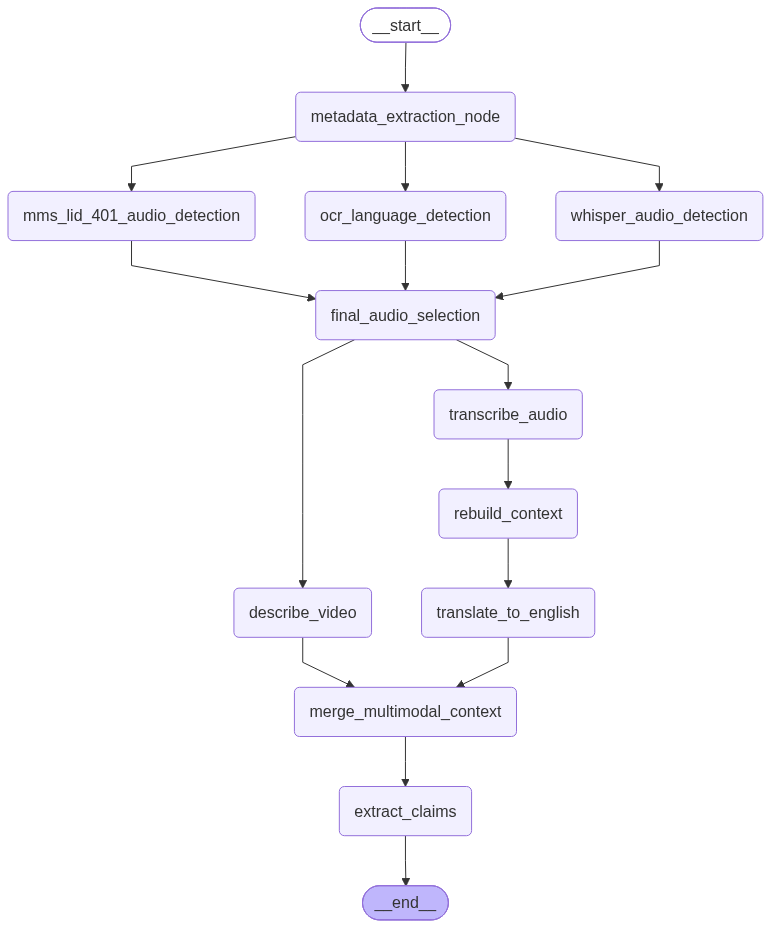

In [28]:
workflow

In [16]:
initial_state = {"video_path" : "D:/factlens/video.mp4"}

final_state = workflow.invoke(initial_state)

print(final_state)

Using CPU. Note: This module is much faster with a GPU.
d:\factlens\.venv\Lib\site-packages\speechbrain\utils\fetching.py:153: UserWarning: Using SYMLINK strategy on Windows for fetching potentially requires elevated privileges and is not recommended. See `LocalStrategy` documentation.
  warnings.warn(


[SpeechBrain Error] [WinError 1314] A required privilege is not held by the client: 'C:\\Users\\rudra\\.cache\\huggingface\\hub\\models--speechbrain--lang-id-commonlanguage_ecapa\\snapshots\\9d809a7e1fdf48afa53e1b41ee8ae0af9ce46308\\hyperparams.yaml' -> 'd:\\factlens\\model_cache\\sb_cv\\hyperparams.yaml'
[VoxLingua Error] [WinError 1314] A required privilege is not held by the client: 'C:\\Users\\rudra\\.cache\\huggingface\\hub\\models--speechbrain--lang-id-voxlingua107-ecapa\\snapshots\\0253049ae131d6a4be1c4f0d8b0ff483a0f8c8e9\\hyperparams.yaml' -> 'd:\\factlens\\model_cache\\sb_vox\\hyperparams.yaml'


Loading weights: 100%|██████████| 1098/1098 [00:01<00:00, 1059.19it/s]
Using CPU. Note: This module is much faster with a GPU.
d:\factlens\.venv\Lib\site-packages\speechbrain\dataio\dataloader.py:225: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  self.__old_init__(loader, *args, **kwargs)


{'video_path': 'D:/factlens/video.mp4', 'valid': True, 'readable': True, 'filename': 'video.mp4', 'extension': '.mp4', 'mime_type': 'video/mp4', 'file_size_bytes': 5144107, 'file_size_mb': 4.91, 'duration_seconds': 49.57, 'fps': 30.0, 'frame_count': 1487, 'resolution': '360x640', 'whisper_result': {'audio_languages': ['hi']}, 'mms_result': {'audio_languages': ['hi']}, 'vox_result': {'audio_languages': []}, 'speechbrain_result': {'audio_languages': []}, 'audio_languages': ['hi'], 'ocr_languages': ['hi'], 'audio_path': 'temp1\\video.wav'}


In [16]:
print(final_state.get("audio_languages")[0])

hi
